# Perform object detection with pollen-vision

Learn how to perform zero shot object detection with the pollen-vision library, using the OWL-ViT model.

This notebook will show you how to use our wrapper for the OWL-ViT object detection model developed by the Google Research lab. 

![Gif Object detection from Reachy's egocentric view](https://media.githubusercontent.com/media/pollen-robotics/pollen-vision/develop/examples/vision_models_examples/gif/reachy_kitchen_detection.gif)

## A word on OWL-ViT
OWL-ViT stands for Vision Transformer for Open-World Localization. It is a zero shot object detection model, meaning the model is able to perform object detection based on text queries, without needing to retrain the model on any labeled data, as it is the case with traditional Deep Learning object detection models.

You can find more information on the model on the dedicated page of the [Hugging Face documentation](https://huggingface.co/docs/transformers/model_doc/owlvit). The implementation of the wrapper actually uses Hugging Face's [transformers library](https://huggingface.co/docs/transformers/index).

## Setup environment

> Note: If you are working locally on your machine and have already installed the library from source, discard the following.

We need to first install the pollen-vision library. We will install the library from source, this might take a couple of minutes as there are quite heavy dependencies.

> If you are on Colab a warning window pops up indicating "You must restart the runtime in order to use the newly installed versions." don't worry. Just press restart session and don't execute the pip install cell again, pollen-vision will already be installed.

In [1]:
!pip install "pollen-vision[vision] @ git+https://github.com/pollen-robotics/pollen-vision.git@main"

  Cloning https://github.com/pollen-robotics/pollen-vision.git (to revision main) to /tmp/pip-install-ahyx9xvt/pollen-vision_b46631e94c7b43cebdacae208bc2ba9f
  Running command git clone --filter=blob:none --quiet https://github.com/pollen-robotics/pollen-vision.git /tmp/pip-install-ahyx9xvt/pollen-vision_b46631e94c7b43cebdacae208bc2ba9f
  Running command git checkout -b main --track origin/main
  Switched to a new branch 'main'
  Branch 'main' set up to track remote branch 'main' from 'origin'.
  Resolved https://github.com/pollen-robotics/pollen-vision.git to commit e17a6b7238f5904403317f47eec74dcf7a96f8ae
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/pollen-robotics/MobileSAM to /tmp/pip-install-ahyx9xvt/mobile-sam_fd8d1d67168242ff95c3f58e4295d854
  Running command git clone --filter=blob:none --quiet https://github.com/pollen-robotics/MobileSAM /tmp/pip-install-ahyx9

## Use OWL-ViT

Let's use the OwlViT wrapper to perform zero shot object detection.

In [2]:
import numpy as np
from PIL import Image

from pollen_vision.vision_models.object_detection import OwlVitWrapper

/home/nikolaraicevic/Workspace/Internal/Reachy_Pollen/reachy2/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
object_detection_wrapper = OwlVitWrapper()

Could not find image processor class in the image processor config or the model config. Loading based on pattern matching with the model's feature extractor configuration. Please open a PR/issue to update `preprocessor_config.json` to use `image_processor_type` instead of `feature_extractor_type`. This warning will be removed in v4.40.


## Import example image

Here we will import an example image to test the OwlViT wrapper. We will use an image from the [reachy-doing-things image dataset](https://huggingface.co/datasets/pollen-robotics/reachy-doing-things) available on Hugging Face. In this dataset, we captured images from an egocentric view of Reachy doing manipulation tasks while being teleoperated.

Feel fry to try the object detection with your own image instead!

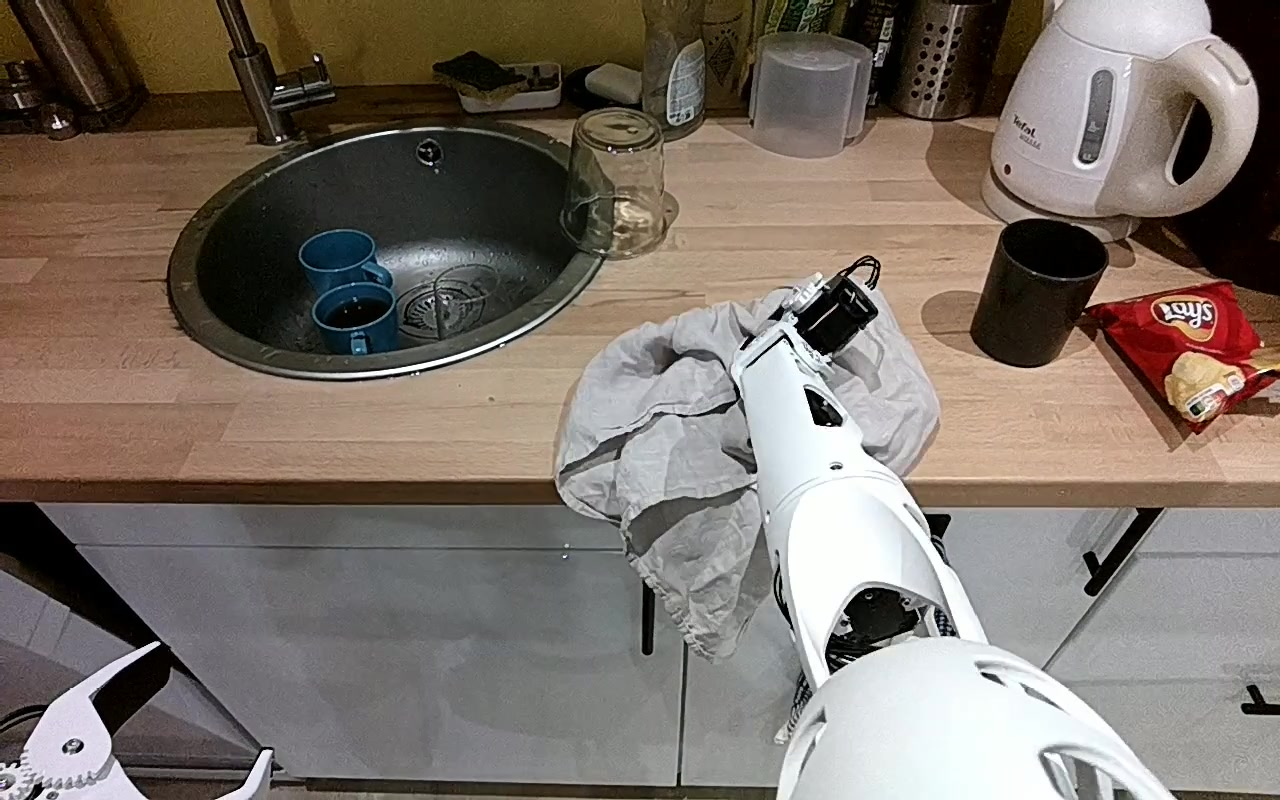

In [4]:
from datasets import load_dataset

dataset = load_dataset("pollen-robotics/reachy-doing-things", split="train")

img = dataset[11]["image"]
img

## Run inference with the model

As explained, the OWL-ViT model is a zero shot object detection model and takes text queries as input. The inference is performed with the *infer* method. Just pass as argument a list of the candidate for the object detection that you want to detect. OWL-ViT will only try to detect classes that are in the list.

NB: Please note that the image passed as argument for the *infer* method must be a **numpy array object**.

In [33]:
predictions = object_detection_wrapper.infer(
    im=np.array(img),
    candidate_labels=["kettle", "black mug", "countertop", "sink", "blue mug", "sponge", "bag of chips","plastic container", "glass cup", "soap","dish soap"],
    detection_threshold=0.15,
)

predictions

[{'score': 0.3089340031147003,
  'label': 'kettle',
  'box': {'xmin': 991, 'ymin': -4, 'xmax': 1266, 'ymax': 225}},
 {'score': 0.2652114927768707,
  'label': 'blue mug',
  'box': {'xmin': 296, 'ymin': 228, 'xmax': 399, 'ymax': 349}},
 {'score': 0.2525648772716522,
  'label': 'sink',
  'box': {'xmin': 162, 'ymin': 118, 'xmax': 621, 'ymax': 380}},
 {'score': 0.19630728662014008,
  'label': 'bag of chips',
  'box': {'xmin': 1077, 'ymin': 279, 'xmax': 1277, 'ymax': 443}},
 {'score': 0.18654870986938477,
  'label': 'black mug',
  'box': {'xmin': 970, 'ymin': 219, 'xmax': 1117, 'ymax': 368}},
 {'score': 0.16562889516353607,
  'label': 'countertop',
  'box': {'xmin': -7, 'ymin': 94, 'xmax': 1267, 'ymax': 497}}]

Change the candidates list and check what you can detect!

### Visualize detection results

You can visualize easliy the predictions of the model with the *Annotator* class from utils.

In [34]:
from pollen_vision.utils import Annotator

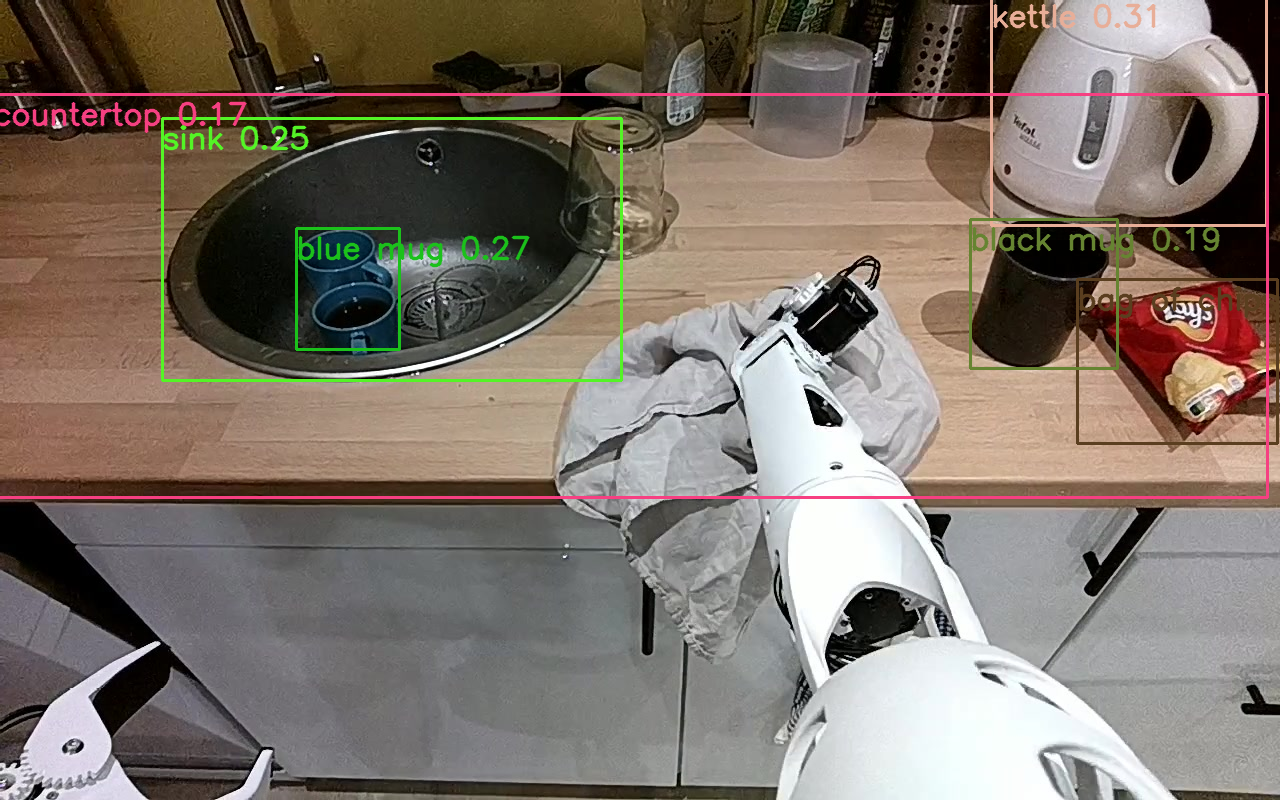

In [35]:
annotator = Annotator()

img_annotated = annotator.annotate(im=np.array(img), detection_predictions=predictions)
Image.fromarray(img_annotated)  # annotator returns a numpy array object

## Final notes

That's all folks! You can use [this script](https://github.com/pollen-robotics/pollen-vision/blob/99-make-the-notebooks-runnable-on-google-colab/scripts/annotate_video.py) if you want to perform zero shot object detection on a recorded video. The scripts gathers every commands that you saw here in the notebook.

Check out the [other notebooks](https://drive.google.com/drive/folders/1Xx42Pk4exkS95iyD-5arHIYQLXyRWTXw?usp=drive_link) if you want to learn how to use other vision models like RAM for image tagging or SAM to perform object segmentation.